# 01 — Data Overview & Cleaning

Khám phá dữ liệu giá cổ phiếu (OHLCV) và làm sạch: kiểm tra logic giá hợp
lệ, loại bỏ ngày trùng lặp.

**Input**: `data/raw/stock_prices.csv`
**Output**: `data/processed/stock_prices_clean.csv`

> Để chạy trên dữ liệu thật: cài `yfinance` (`pip install yfinance`), tải
> dữ liệu bằng `yf.download("AAPL", start="2022-01-01", end="2024-01-01")`,
> lưu vào `data/raw/stock_prices.csv` với cùng cấu trúc cột.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.data_processing import load_price_data, basic_data_quality_check, clean_price_data, save_processed

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = "../data/raw/stock_prices.csv"

## 1. Đọc dữ liệu

In [2]:
raw = load_price_data(DATA_PATH)
print(f"Dữ liệu: {raw.shape[0]:,} ngày giao dịch")
print(f"Khoảng thời gian: {raw['Date'].min().date()} -> {raw['Date'].max().date()}")
raw.head()

Dữ liệu: 750 ngày giao dịch
Khoảng thời gian: 2022-01-03 -> 2024-11-15


,Date,Open,High,Low,Close,Volume
0,2022-01-03,150.050,150.530,149.160,150.000,5222478
1,2022-01-04,151.260,152.220,150.690,151.650,4416259
2,2022-01-05,148.770,151.440,146.380,148.590,4863610
3,2022-01-06,152.750,156.280,149.610,152.530,7327190
4,2022-01-07,150.620,152.500,149.020,150.380,5111961


## 2. Cấu trúc dữ liệu OHLCV

- `Open`, `High`, `Low`, `Close`: giá mở cửa, cao nhất, thấp nhất, đóng cửa
- `Volume`: khối lượng giao dịch

Logic hợp lệ bắt buộc: `High` phải >= tất cả các giá khác trong ngày,
`Low` phải <= tất cả các giá khác trong ngày.

In [3]:
raw.describe()

,Date,Open,High,Low,Close,Volume
count,750,750.000,750.000,750.000,750.000,750.000
mean,2023-06-10 12:00:00,264.891,269.083,260.737,264.903,"5,922,198.200"
min,2022-01-03 00:00:00,111.080,112.240,108.400,111.470,"4,006,878.000"
25%,2022-09-21 06:00:00,230.095,232.865,226.683,230.433,"5,059,064.750"
50%,2023-06-10 12:00:00,275.630,279.775,270.830,275.700,"5,877,083.500"
75%,2024-02-27 18:00:00,320.873,324.898,315.723,320.605,"6,831,064.000"
max,2024-11-15 00:00:00,369.510,389.300,366.980,369.580,"8,863,271.000"
std,NaN,67.971,69.105,66.988,67.988,"1,055,353.551"


## 3. Kiểm tra chất lượng dữ liệu

In [4]:
stats = basic_data_quality_check(raw)
for k, v in stats.items():
    print(f"{k}: {v}")

n_rows: 750
date_range: (Timestamp('2022-01-03 00:00:00'), Timestamp('2024-11-15 00:00:00'))
n_duplicate_dates: 0
n_invalid_ohlc: 0
n_zero_or_negative: 0
n_missing: 0


## 4. Làm sạch dữ liệu

In [5]:
clean = clean_price_data(raw)

Số dòng ban đầu:              750
Bỏ do ngày trùng lặp:          0
Bỏ do giá/volume <= 0:         0
Bỏ do vi phạm logic OHLC:      0
Số dòng còn lại:               750


## 5. Biểu đồ giá tổng quan (kiểm tra nhanh bằng mắt)

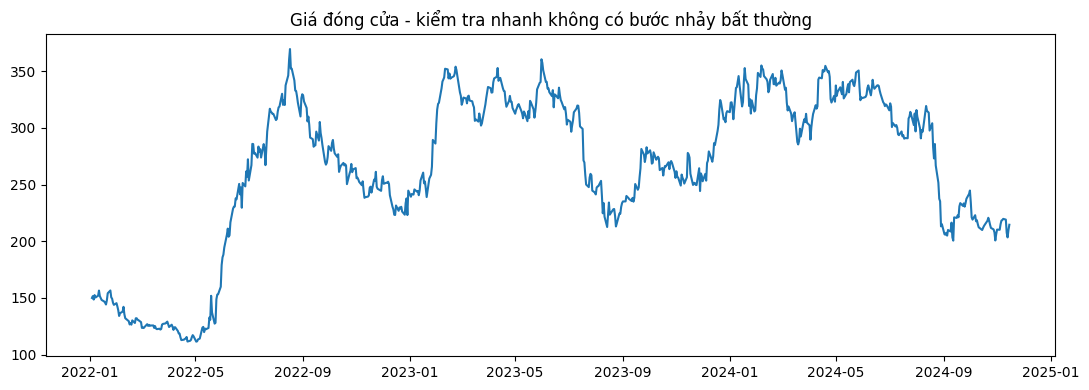

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(clean["Date"], clean["Close"])
ax.set_title("Giá đóng cửa - kiểm tra nhanh không có bước nhảy bất thường")
plt.tight_layout()
plt.show()

## 6. Lưu dữ liệu đã xử lý

In [7]:
save_processed(clean, "../data/processed/stock_prices_clean.csv")

Đã lưu -> ../data/processed/stock_prices_clean.csv
